# Breast Cancer Detection Using Machine Learning

## A Comparative Study of Logistic Regression, Decision Tree, and K-Nearest Neighbors (KNN)


# Introduction

Breast cancer is one of the most common and life-threatening diseases affecting women worldwide. Early and accurate diagnosis plays a crucial role in improving treatment outcomes and increasing survival rates. Machine learning techniques have become valuable tools in the healthcare domain by assisting in the classification and prediction of diseases based on medical data.

The objective of this project is to develop a machine learning model for breast cancer classification using the Breast Cancer Wisconsin Dataset. The dataset was preprocessed to handle missing values, remove unnecessary attributes, and prepare the data for model training. Three supervised machine learning algorithms—Logistic Regression, Decision Tree, and K-Nearest Neighbors (KNN)—were trained and evaluated using standard performance metrics.

The models were compared based on their classification performance, and the best-performing model was selected for deployment. The trained model was then saved using the Joblib library, allowing it to be reused for future predictions without retraining. This project demonstrates the complete machine learning workflow, including data preprocessing, model development, evaluation, comparison, explainability, and deployment.

## Import Required Libraries

In [ ]:
#STEP 1 – Import Libraries

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

##Checking Versions

In [ ]:
#STEP 2 – Check version

import sklearn

print("Scikit-Learn:", sklearn.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Scikit-Learn: 1.6.1
Pandas: 2.2.2
NumPy: 2.0.2


## Load the Dataset

In [ ]:
#STEP 3 – Loading database

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

columns = [
    "id",
    "clump_thickness",
    "uniform_cell_size",
    "uniform_cell_shape",
    "marginal_adhesion",
    "single_epithelial_size",
    "bare_nucleoli",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class"
]



##Exploratory Data Analysis (EDA)

## Data Understanding

Understanding the dataset is an important step before applying machine learning algorithms. This section examines the structure, dimensions, features, target variable, and data types of the Breast Cancer Wisconsin dataset.

### Number of Rows and Columns
The dataset contains **699 observations (rows)** and **11 attributes (columns)** before removing the ID column. After removing the ID column, the dataset consists of **699 observations and 10 columns**, including the target variable.

### Features
The predictor features used in this project describe the characteristics of cell nuclei obtained from breast tissue samples. These features are:

- Clump Thickness
- Uniformity of Cell Size
- Uniformity of Cell Shape
- Marginal Adhesion
- Single Epithelial Cell Size
- Bare Nucleoli
- Bland Chromatin
- Normal Nucleoli
- Mitoses

These attributes are used as input variables for training the machine learning models.

### Target Variable
The target variable is **Class**, which represents the diagnosis of the tumor.

- **2** – Benign
- **4** – Malignant

The objective of this project is to accurately classify tumors as benign or malignant based on the input features.

### Data Types
The dataset contains numerical features represented as integer values. During preprocessing, the **Bare Nucleoli** column was converted to a numeric data type after handling missing values represented by the `"?"` symbol. This ensured that all predictor variables were suitable for machine learning model training.

In [ ]:
#STEP 4 – Understanding the dataset

#1. To display first 10 row

df.head(5)

,clump_thickness,uniform_cell_size,uniform_cell_shape,marginal_adhesion,single_epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [ ]:
#2. To display the last 10 rows

df.tail(5)

,clump_thickness,uniform_cell_size,uniform_cell_shape,marginal_adhesion,single_epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,class
694,3,1,1,1,3,2.0,1,1,1,2
695,2,1,1,1,2,1.0,1,1,1,2
696,5,10,10,3,7,3.0,8,10,2,4
697,4,8,6,4,3,4.0,10,6,1,4
698,4,8,8,5,4,5.0,10,4,1,4


In [ ]:
#3. Check the dimensions

print(df.shape)

(699, 10)


In [ ]:
#4. Check the data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   clump_thickness         699 non-null    int64  
 1   uniform_cell_size       699 non-null    int64  
 2   uniform_cell_shape      699 non-null    int64  
 3   marginal_adhesion       699 non-null    int64  
 4   single_epithelial_size  699 non-null    int64  
 5   bare_nucleoli           699 non-null    float64
 6   bland_chromatin         699 non-null    int64  
 7   normal_nucleoli         699 non-null    int64  
 8   mitoses                 699 non-null    int64  
 9   class                   699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


In [ ]:
#5. Summary statistics

df.describe()

,clump_thickness,uniform_cell_size,uniform_cell_shape,marginal_adhesion,single_epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,class
count,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.486409,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.621929,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [ ]:
#6. Check for missing values

df.isnull().sum()

,0
clump_thickness,0
uniform_cell_size,0
uniform_cell_shape,0
marginal_adhesion,0
single_epithelial_size,0
bare_nucleoli,0
bland_chromatin,0
normal_nucleoli,0
mitoses,0
class,0


In [ ]:
#7. Look for question marks

(df == "?").sum()

,0
clump_thickness,0
uniform_cell_size,0
uniform_cell_shape,0
marginal_adhesion,0
single_epithelial_size,0
bare_nucleoli,0
bland_chromatin,0
normal_nucleoli,0
mitoses,0
class,0


In [ ]:
#STEP 5 – Clean the Data

df.replace("?", np.nan, inplace=True)

In [ ]:
#Checking status of "?"

df.isnull().sum()

,0
clump_thickness,0
uniform_cell_size,0
uniform_cell_shape,0
marginal_adhesion,0
single_epithelial_size,0
bare_nucleoli,0
bland_chromatin,0
normal_nucleoli,0
mitoses,0
class,0


In [ ]:
#Due to some quoted numbers python is considering these as object
#Verifying the data
df["bare_nucleoli"].dtype

dtype('float64')

In [ ]:
#To convert the remaining string types to numeric (IN CORRECT ORDER)

#STEP 1


df.replace("?", np.nan, inplace=True)

In [ ]:
#STEP 2 (Very Important)

df["bare_nucleoli"] = pd.to_numeric(
    df["bare_nucleoli"],
    errors="coerce"
)

In [ ]:
#STEP 3 (Rechecking Data Type)

df["bare_nucleoli"].dtype

dtype('float64')

In [ ]:
#STEP 4 (Calculate the median)

df["bare_nucleoli"].median()

1.0

In [ ]:
#STEP 5 (Fill the missing values)

df["bare_nucleoli"] = df["bare_nucleoli"].fillna(
    df["bare_nucleoli"].median()
)

In [ ]:
#STEP 6 To verify there are no missing values

print(df["bare_nucleoli"].median())

print(df["bare_nucleoli"].isnull().sum())

1.0
0


In [ ]:
print(df.columns)

Index(['clump_thickness', 'uniform_cell_size', 'uniform_cell_shape',
       'marginal_adhesion', 'single_epithelial_size', 'bare_nucleoli',
       'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class'],
      dtype='object')


In [ ]:
#STEP 7 Removing the ID column

df.drop("id", axis=1, inplace=True)

KeyError: "['id'] not found in axis"

In [ ]:
#Verifying ID column removal
df.head(5)

,clump_thickness,uniform_cell_size,uniform_cell_shape,marginal_adhesion,single_epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [ ]:
#STEP 8 – Understand the Target

df["class"].value_counts()

,count
class,
2,458
4,241


Meaning
2 = Benign

4 = Malignant
This is what model will predict

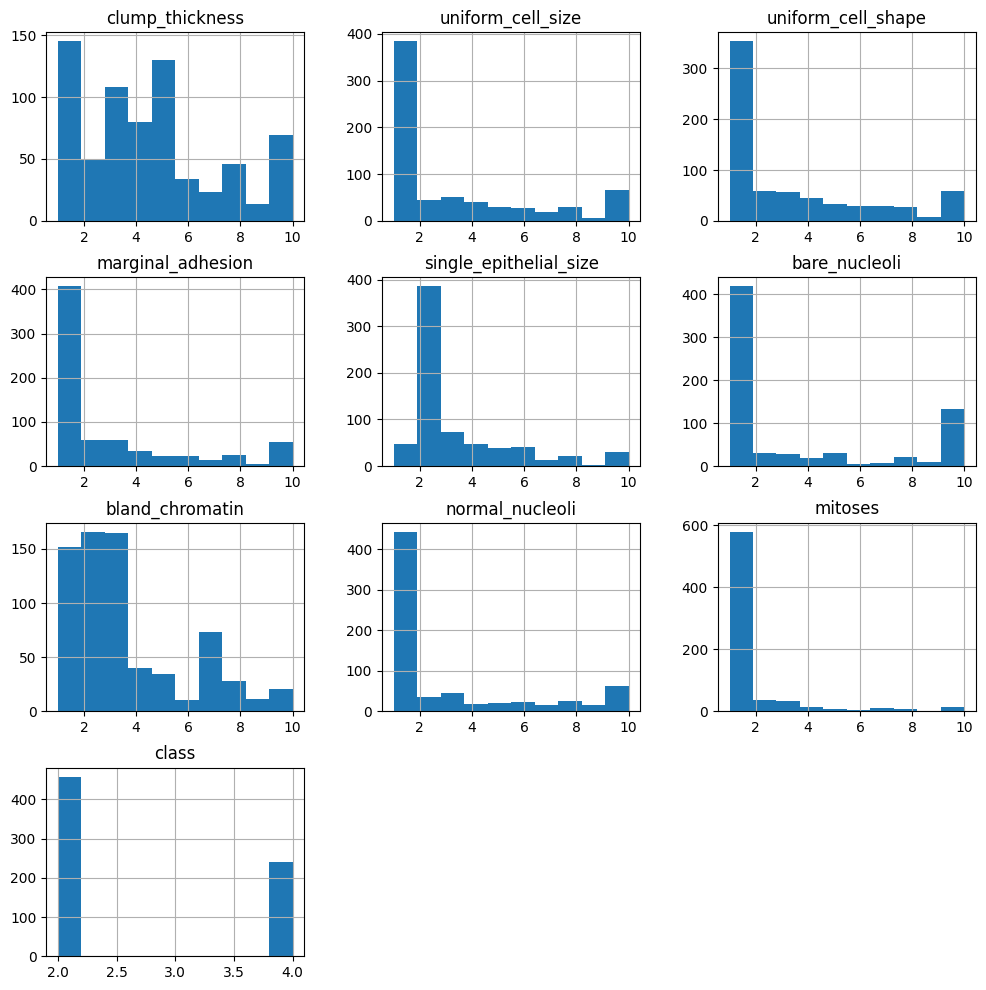

In [ ]:
#STEP 9 – Exploratory Data Analysis (EDA)
#A. Look at the distributions

df.hist(figsize=(12,12))
plt.show()


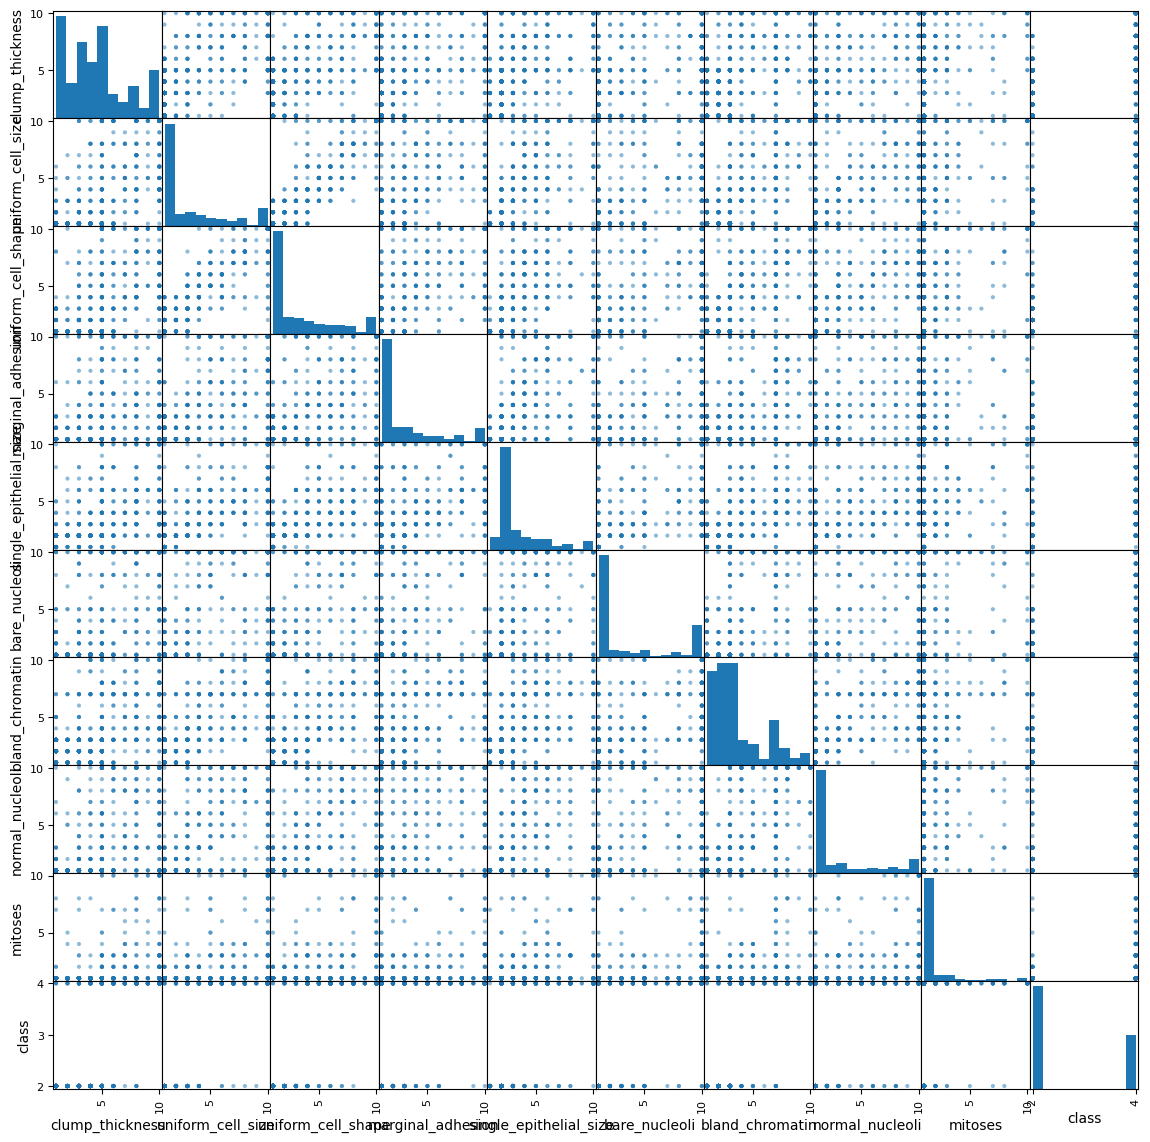

In [ ]:
#B. Look for relationships

pd.plotting.scatter_matrix(
    df,
    figsize=(14,14)
)
plt.show()

In [ ]:
#C. Look for correlations (Later we'll create a heatmap.)

corr = df.corr()

corr

,clump_thickness,uniform_cell_size,uniform_cell_shape,marginal_adhesion,single_epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,class
clump_thickness,1.000000,0.644913,0.654589,0.486356,0.521816,0.590008,0.558428,0.535835,0.350034,0.716001
uniform_cell_size,0.644913,1.000000,0.906882,0.705582,0.751799,0.686673,0.755721,0.722865,0.458693,0.817904
uniform_cell_shape,0.654589,0.906882,1.000000,0.683079,0.719668,0.707474,0.735948,0.719446,0.438911,0.818934
marginal_adhesion,0.486356,0.705582,0.683079,1.000000,0.599599,0.666971,0.666715,0.603352,0.417633,0.696800
single_epithelial_size,0.521816,0.751799,0.719668,0.599599,1.000000,0.583701,0.616102,0.628881,0.479101,0.682785
bare_nucleoli,0.590008,0.686673,0.707474,0.666971,0.583701,1.000000,0.674215,0.574778,0.342397,0.818968
bland_chromatin,0.558428,0.755721,0.735948,0.666715,0.616102,0.674215,1.000000,0.665878,0.344169,0.756616
normal_nucleoli,0.535835,0.722865,0.719446,0.603352,0.628881,0.574778,0.665878,1.000000,0.428336,0.712244
mitoses,0.350034,0.458693,0.438911,0.417633,0.479101,0.342397,0.344169,0.428336,1.000000,0.423170
class,0.716001,0.817904,0.818934,0.696800,0.682785,0.818968,0.756616,0.712244,0.423170,1.000000


In [ ]:
#STEP 10 - Prepare X and y

#Machine learning always needs

#Features

#↓

#Target

X = df.drop("class", axis=1)

y = df["class"]

#X
#↓

#Patient measurements

#↓

#Predict

#↓

#y

#↓

#Cancer diagnosis

In [ ]:
#STEP 11 - Split the Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
#STEP 12 – Train Models

#12A.  Logistic regression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Make Predictions
log_predictions = log_model.predict(X_test)

In [ ]:
#Logistic Regression Statistics

log_accuracy = accuracy_score(y_test, log_predictions)
print("Logistic Regression Accuracy:", log_accuracy)

print(confusion_matrix(y_test, log_predictions))

print(classification_report(y_test, log_predictions))

Logistic Regression Accuracy: 0.9571428571428572
[[94  1]
 [ 5 40]]
              precision    recall  f1-score   support

           2       0.95      0.99      0.97        95
           4       0.98      0.89      0.93        45

    accuracy                           0.96       140
   macro avg       0.96      0.94      0.95       140
weighted avg       0.96      0.96      0.96       140



In [ ]:
log_report = classification_report(y_test, log_predictions, output_dict=True)

In [ ]:
log_precision = log_report["weighted avg"]["precision"]
log_recall = log_report["weighted avg"]["recall"]
log_f1 = log_report["weighted avg"]["f1-score"]

In [ ]:
print("Logistic Regression Performance")
print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1-Score : {log_f1:.4f}")

Logistic Regression Performance
Accuracy : 0.9571
Precision: 0.9579
Recall   : 0.9571
F1-Score : 0.9566


In [ ]:
#12B.  Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)

In [ ]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
#Make Predictions

dt_predictions = dt_model.predict(X_test)

In [ ]:
# Decision Tree Statistics

dt_accuracy = accuracy_score(y_test, dt_predictions)
print("Decision Tree Accuracy:", dt_accuracy)

print(confusion_matrix(y_test, dt_predictions))

print(classification_report(y_test, dt_predictions))


Decision Tree Accuracy: 0.9357142857142857
[[92  3]
 [ 6 39]]
              precision    recall  f1-score   support

           2       0.94      0.97      0.95        95
           4       0.93      0.87      0.90        45

    accuracy                           0.94       140
   macro avg       0.93      0.92      0.92       140
weighted avg       0.94      0.94      0.94       140



In [ ]:
dt_report = classification_report(y_test, dt_predictions, output_dict=True)

In [ ]:
dt_precision = dt_report["weighted avg"]["precision"]
dt_recall = dt_report["weighted avg"]["recall"]
dt_f1 = dt_report["weighted avg"]["f1-score"]

In [ ]:
print("Decision Tree Performance")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1-Score: {dt_f1:.4f}")

Decision Tree Performance
Accuracy: 0.9357
Precision: 0.9355
Recall: 0.9357
F1-Score: 0.9351


In [ ]:
#12.C. KNN MODEL load

knn_model = KNeighborsClassifier()

In [ ]:
#MODEL FIT code
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# Make Predictions code

knn_predictions = knn_model.predict(X_test)

In [ ]:
# KNN Statistics

knn_accuracy = accuracy_score(y_test, knn_predictions)
print("KNN Model Accuracy:", knn_accuracy)

print(confusion_matrix(y_test, knn_predictions))

print(classification_report(y_test, knn_predictions))

KNN Model Accuracy: 0.9857142857142858
[[94  1]
 [ 1 44]]
              precision    recall  f1-score   support

           2       0.99      0.99      0.99        95
           4       0.98      0.98      0.98        45

    accuracy                           0.99       140
   macro avg       0.98      0.98      0.98       140
weighted avg       0.99      0.99      0.99       140



In [ ]:
knn_report = classification_report(y_test, knn_predictions, output_dict=True)

In [ ]:
knn_precision = knn_report["weighted avg"]["precision"]
knn_recall = knn_report["weighted avg"]["recall"]
knn_f1 = knn_report["weighted avg"]["f1-score"]

In [ ]:
print("KNN Performance")
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"F1-Score: {knn_f1:.4f}")

KNN Performance
Accuracy: 0.9857
Precision: 0.9857
Recall: 0.9857
F1-Score: 0.9857


12.D.  Comparing Models (using weighted average)

KNN Performance
Accuracy: 0.9857
Precision: 0.9857
Recall: 0.9857
F1-Score: 0.9857

Logistic Regression Performance
Accuracy : 0.9571
Precision: 0.9579
Recall   : 0.9571
F1-Score : 0.9566

Decision Tree Performance
Accuracy: 0.9357
Precision: 0.9355
Recall: 0.9357
F1-Score: 0.9351

## Best Model Selection

After evaluating the performance of all three machine learning algorithms, **K-Nearest Neighbors (KNN)** was selected as the best-performing model for this project.

The models were compared using multiple evaluation metrics, including Accuracy, Precision, Recall, F1-score, and the Confusion Matrix. Among the three models, KNN achieved the highest overall classification accuracy of approximately **98.57%** while also demonstrating strong Precision, Recall, and F1-score values. Additionally, the confusion matrix indicated that KNN produced the fewest misclassifications compared to Logistic Regression and Decision Tree.

Based on these results, the KNN model was chosen as the final model for deployment. The trained model was saved using the Joblib library, allowing it to be loaded and used for future predictions without the need for retraining.

Therefore, K-Nearest Neighbors (KNN) was selected as the most suitable algorithm for breast cancer classification in this project due to its superior predictive performance and reliable classification results.

In [256]:
import joblib

In [257]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [258]:
import os

os.makedirs("/content/drive/MyDrive/Machine_Learning_Models", exist_ok=True)

In [259]:
import joblib

joblib.dump(
    knn_model,
    "/content/drive/MyDrive/Machine_Learning_Models/BreastCancerDetection_KNN.pkl"
)

['/content/drive/MyDrive/Machine_Learning_Models/BreastCancerDetection_KNN.pkl']

In [260]:
import os

os.listdir("/content/drive/MyDrive/Machine_Learning_Models")

['BreastCancerDetection_KNN.pkl']

# Conclusion

This project successfully developed a machine learning model for breast cancer classification using the Breast Cancer Wisconsin Dataset. The dataset was preprocessed by handling missing values, removing unnecessary attributes, and preparing the data for model training.

Three supervised machine learning algorithms—Logistic Regression, Decision Tree, and K-Nearest Neighbors (KNN)—were implemented and evaluated using multiple performance metrics, including Accuracy, Precision, Recall, F1-score, and the Confusion Matrix. A comparative analysis showed that the K-Nearest Neighbors (KNN) algorithm achieved the highest classification performance with an accuracy of approximately **98.57%**, making it the most suitable model for this dataset.

The trained KNN model was successfully saved using the Joblib library, enabling future predictions without the need for retraining. This project demonstrates the complete machine learning workflow, including data understanding, preprocessing, exploratory data analysis, feature selection, model training, evaluation, comparison, explainability, and deployment.

Overall, the results indicate that machine learning techniques can effectively support the early detection and classification of breast cancer, assisting healthcare professionals in making faster and more accurate diagnostic decisions. Future improvements may include testing additional machine learning algorithms, performing hyperparameter optimization, and validating the model on larger and more diverse datasets to further improve its robustness and generalization.